In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_train_data = pd.read_parquet(
    "../data/processed/train_dqi_output.parquet"
)

### Univariate Data Analysis

In [3]:
raw_train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_util_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

In [4]:
train_data = raw_train_data.copy(deep=True)

f_dpd_90plus_nxt_2yrs
0    139974
1     10026
Name: count, dtype: int64



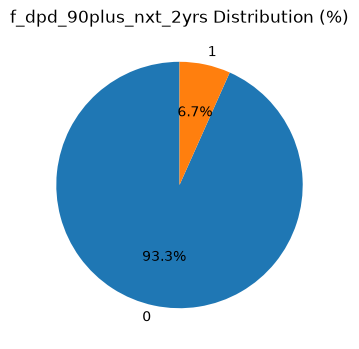

In [5]:
#f_dpd_90plus_nxt_2yrs - response variable
print(train_data["f_dpd_90plus_nxt_2yrs"].value_counts())
print()

uniq_cnts = train_data["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
plt.figure(figsize=(4,4))
plt.pie(
    uniq_cnts.values,
    labels=uniq_cnts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("f_dpd_90plus_nxt_2yrs Distribution (%)")
plt.show()

In [6]:
#n_dependents_imp & n_dependents_nan_flag
uniq_cnts_1 = train_data["n_dependents_imp"].value_counts(normalize=True) * 100
uniq_cnts_1 = uniq_cnts_1.sort_values(ascending=False)
print(uniq_cnts_1)
print()
uniq_cnts_2 = train_data["n_dependents_nan_flag"].value_counts(normalize=True) * 100
uniq_cnts_2 = uniq_cnts_2.sort_values(ascending=False)
print(uniq_cnts_2)

n_dependents_imp
0.0     60.550667
1.0     17.544000
2.0     13.014667
3.0      6.322000
4.0      1.908000
5.0      0.497333
6.0      0.105333
7.0      0.034000
8.0      0.016000
10.0     0.003333
9.0      0.003333
20.0     0.000667
13.0     0.000667
Name: proportion, dtype: float64

n_dependents_nan_flag
0    97.384
1     2.616
Name: proportion, dtype: float64


mean monthly income: 6418.45492
median monthly income: 5400.0
minimum monthly income: 0.0
maximum monthly income: 3008750.0


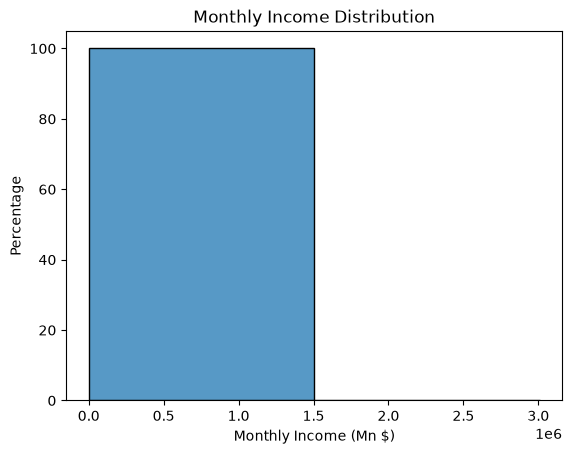

In [ ]:
#monthly_income_imp & monthly_income_nan_flag
print("mean monthly income:", train_data["monthly_income_imp"].mean())
print("median monthly income:", train_data["monthly_income_imp"].median())
print("minimum monthly income:", train_data["monthly_income_imp"].min())
print("maximum monthly income:", train_data["monthly_income_imp"].max())

sns.histplot(train_data["monthly_income_imp"], bins=2, stat="percent")
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income (Mn $)")
plt.ylabel("Percentage")
plt.show()

In [8]:
#monthly_income_imp & monthly_income_nan_flag
print("min_monthly_income:", train_data["monthly_income_imp"].min(), "max_monthly_income:", train_data["monthly_income_imp"].max())
print()
uniq_cnts_1 = train_data["monthly_income_imp"].value_counts(normalize=True) * 100
uniq_cnts_1 = uniq_cnts_1.sort_values(ascending=False)
print(uniq_cnts_1)
print()
uniq_cnts_2 = train_data["monthly_income_nan_flag"].value_counts(normalize=True) * 100
uniq_cnts_2 = uniq_cnts_2.sort_values(ascending=False)
print(uniq_cnts_2)

min_monthly_income: 0.0 max_monthly_income: 3008750.0

monthly_income_imp
5400.0     20.041333
5000.0      1.838000
4000.0      1.404000
6000.0      1.289333
3000.0      1.172000
             ...    
7039.0      0.000667
596.0       0.000667
15648.0     0.000667
521.0       0.000667
7647.0      0.000667
Name: proportion, Length: 13594, dtype: float64

monthly_income_nan_flag
0    80.179333
1    19.820667
Name: proportion, dtype: float64


n_dpd_90plus_hist
0     94.441333
1      3.495333
2      1.036667
3      0.444667
4      0.194000
98     0.176000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
96     0.003333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64



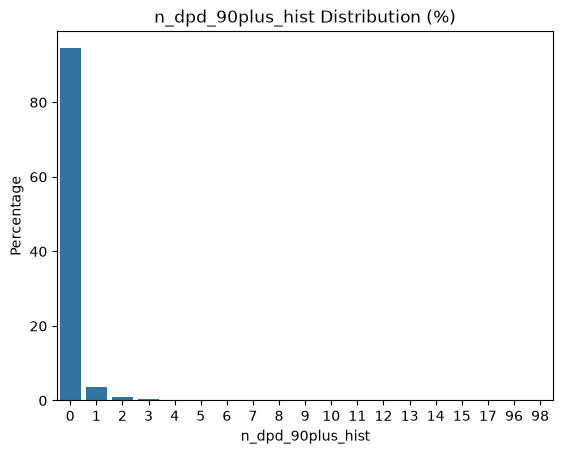

In [9]:
uniq_cnts = train_data["n_dpd_90plus_hist"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_90plus_hist Distribution (%)")
plt.show()

n_dpd_60_89_l2yrs
0     94.930667
1      3.820667
2      0.745333
3      0.212000
98     0.176000
4      0.070000
5      0.022667
6      0.010667
7      0.006000
96     0.003333
8      0.001333
11     0.000667
9      0.000667
Name: proportion, dtype: float64



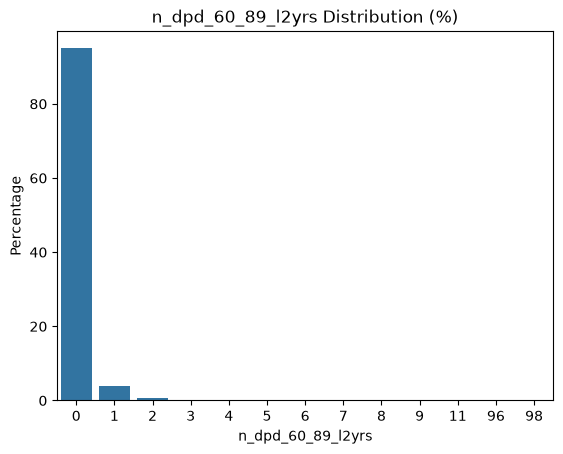

In [10]:
uniq_cnts = train_data["n_dpd_60_89_l2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_60_89_l2yrs Distribution (%)")
plt.show()

n_dpd_30_50_l2yrs
0     84.012000
1     10.688667
2      3.065333
3      1.169333
4      0.498000
5      0.228000
98     0.176000
6      0.093333
7      0.036000
8      0.016667
9      0.008000
96     0.003333
10     0.002667
12     0.001333
13     0.000667
11     0.000667
Name: proportion, dtype: float64



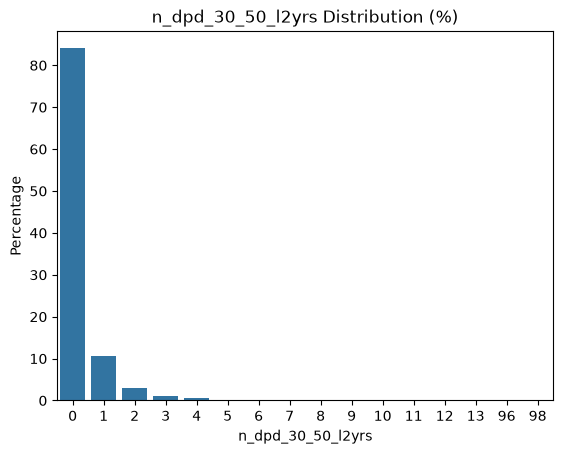

In [11]:
#n_dpd_30_50_l2yrs
uniq_cnts = train_data["n_dpd_30_50_l2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_30_50_l2yrs Distribution (%)")
plt.show()

In [12]:
train_data.loc[train_data["n_dpd_90plus_hist"]==98, :].head()

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,age,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp
1733,id_1734,98,98,98,0,0,1.0,0.0,27,1,0,0,0.0,2700.0
2286,id_2287,98,98,98,0,0,1.0,0.0,22,0,0,1,0.0,5400.0
3884,id_3885,98,98,98,0,0,1.0,12.0,38,0,0,1,0.0,5400.0
4417,id_4418,98,98,98,0,0,1.0,0.0,21,0,0,0,0.0,0.0
4705,id_4706,98,98,98,0,0,1.0,0.0,21,0,0,0,0.0,2000.0


In [13]:
train_data.loc[train_data["n_dpd_90plus_hist"]==96, :].head()

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,age,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp
41944,id_41945,96,96,96,0,0,1.0,0.000000,26,1,0,1,0.0,5400.0
69478,id_69479,96,96,96,0,0,1.0,0.008047,33,1,0,0,0.0,4100.0
84167,id_84168,96,96,96,0,0,1.0,0.000000,29,1,0,0,2.0,2800.0
94106,id_94107,96,96,96,0,0,1.0,0.000000,34,1,0,0,1.0,3500.0
120049,id_120050,96,96,96,0,0,1.0,0.051765,46,0,0,0,0.0,4616.0


min_n_mort_loans: 0 max_n_mort_loans: 54



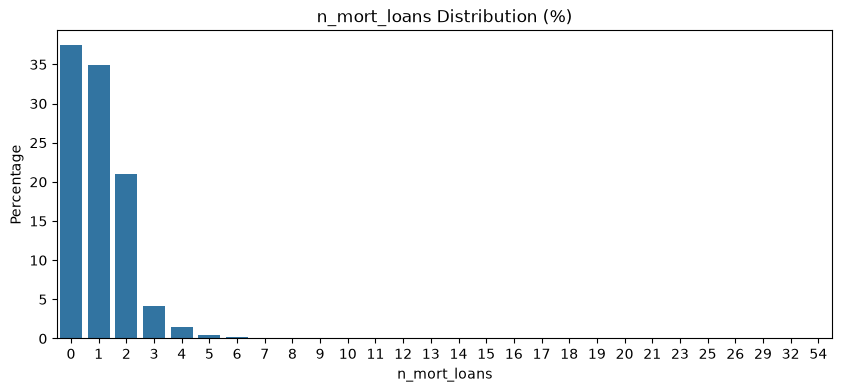

In [14]:
#n_mort_loans
print("min_n_mort_loans:", train_data["n_mort_loans"].min(), "max_n_mort_loans:", train_data["n_mort_loans"].max())
print()
uniq_cnts = train_data["n_mort_loans"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
# print(uniq_cnts)
# print()
plt.figure(figsize=(10, 4))
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_mort_loans Distribution (%)")
plt.show()

min_n_credit_lines: 0 max_n_credit_lines: 58



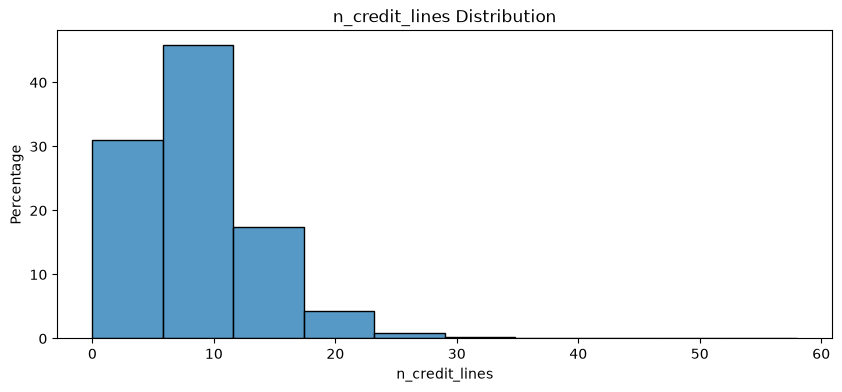

In [15]:
# n_credit_lines
plt.figure(figsize=(10, 4))
print("min_n_credit_lines:", train_data["n_credit_lines"].min(), "max_n_credit_lines:", train_data["n_credit_lines"].max())
print()
sns.histplot(train_data["n_credit_lines"], bins=10, stat="percent")
plt.title("n_credit_lines Distribution")
plt.xlabel("n_credit_lines")
plt.ylabel("Percentage")
plt.show()

min_avg_util_unsec: 0.0 max_avg_util_unsec: 50708.0

mean_avg_util_unsec: 6.048438054666887 median_avg_util_unsec: 0.154180737



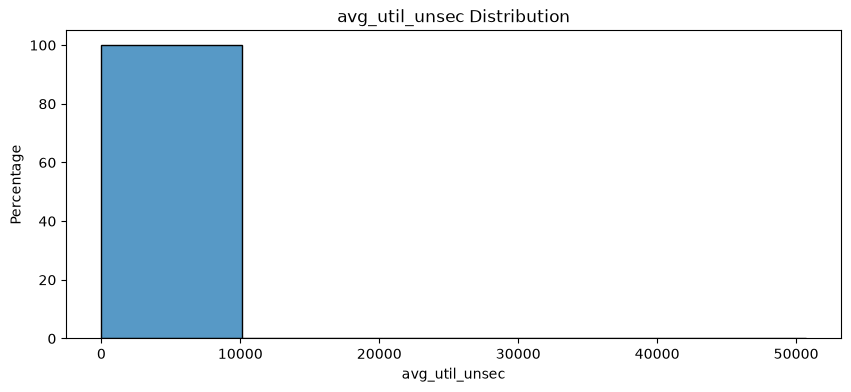

In [16]:
# utilization of unsecured lines
plt.figure(figsize=(10, 4))
print("min_avg_util_unsec:", train_data["avg_util_unsec"].min(), "max_avg_util_unsec:", train_data["avg_util_unsec"].max())
print()
print("mean_avg_util_unsec:", train_data["avg_util_unsec"].mean(), "median_avg_util_unsec:", train_data["avg_util_unsec"].median())
print()
sns.histplot(train_data["avg_util_unsec"], bins=5, stat="percent")
plt.title("avg_util_unsec Distribution")
plt.xlabel("avg_util_unsec")
plt.ylabel("Percentage")
plt.show()

<Axes: xlabel='avg_util_unsec'>

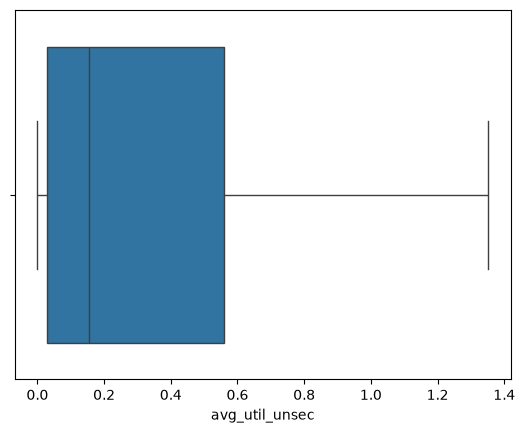

In [17]:
sns.boxplot(x=train_data["avg_util_unsec"], showfliers=False)

min_debt_income_ratio: 0.0 max_debt_income_ratio: 329664.0

mean_debt_income_ratio: 353.00507576386985 median_debt_income_ratio: 0.366507841



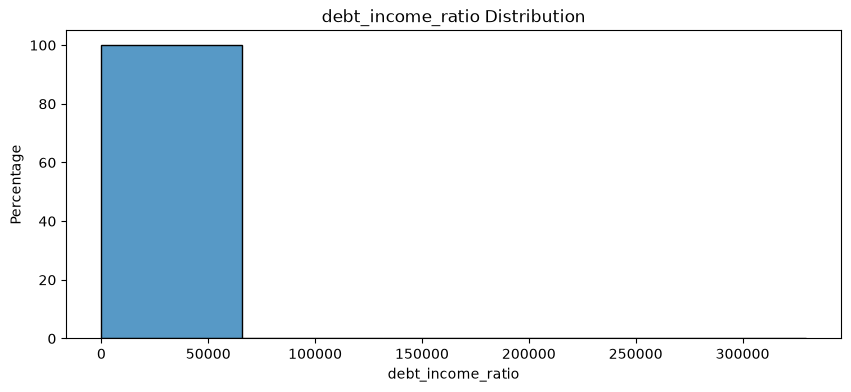

In [18]:
#debt_income_ratio
plt.figure(figsize=(10, 4))
print("min_debt_income_ratio:", train_data["debt_income_ratio"].min(), "max_debt_income_ratio:", train_data["debt_income_ratio"].max())
print()
print("mean_debt_income_ratio:", train_data["debt_income_ratio"].mean(), "median_debt_income_ratio:", train_data["debt_income_ratio"].median())
print()
sns.histplot(train_data["debt_income_ratio"], bins=5, stat="percent")
plt.title("debt_income_ratio Distribution")
plt.xlabel("debt_income_ratio")
plt.ylabel("Percentage")
plt.show()

min_age: 0 max_age: 109

mean_age: 52.295206666666665 median_age: 52.0



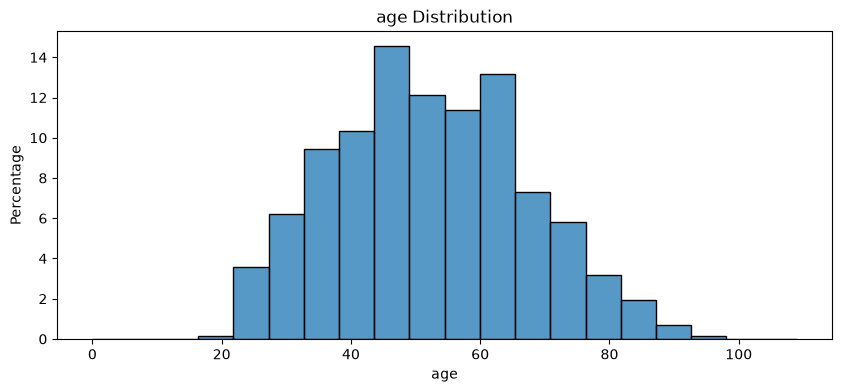

In [19]:
#age
plt.figure(figsize=(10, 4))
print("min_age:", train_data["age"].min(), "max_age:", train_data["age"].max())
print()
print("mean_age:", train_data["age"].mean(), "median_age:", train_data["age"].median())
print()
sns.histplot(train_data["age"], bins=20, stat="percent")
plt.title("age Distribution")
plt.xlabel("age")
plt.ylabel("Percentage")
plt.show()

In [20]:
train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_util_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

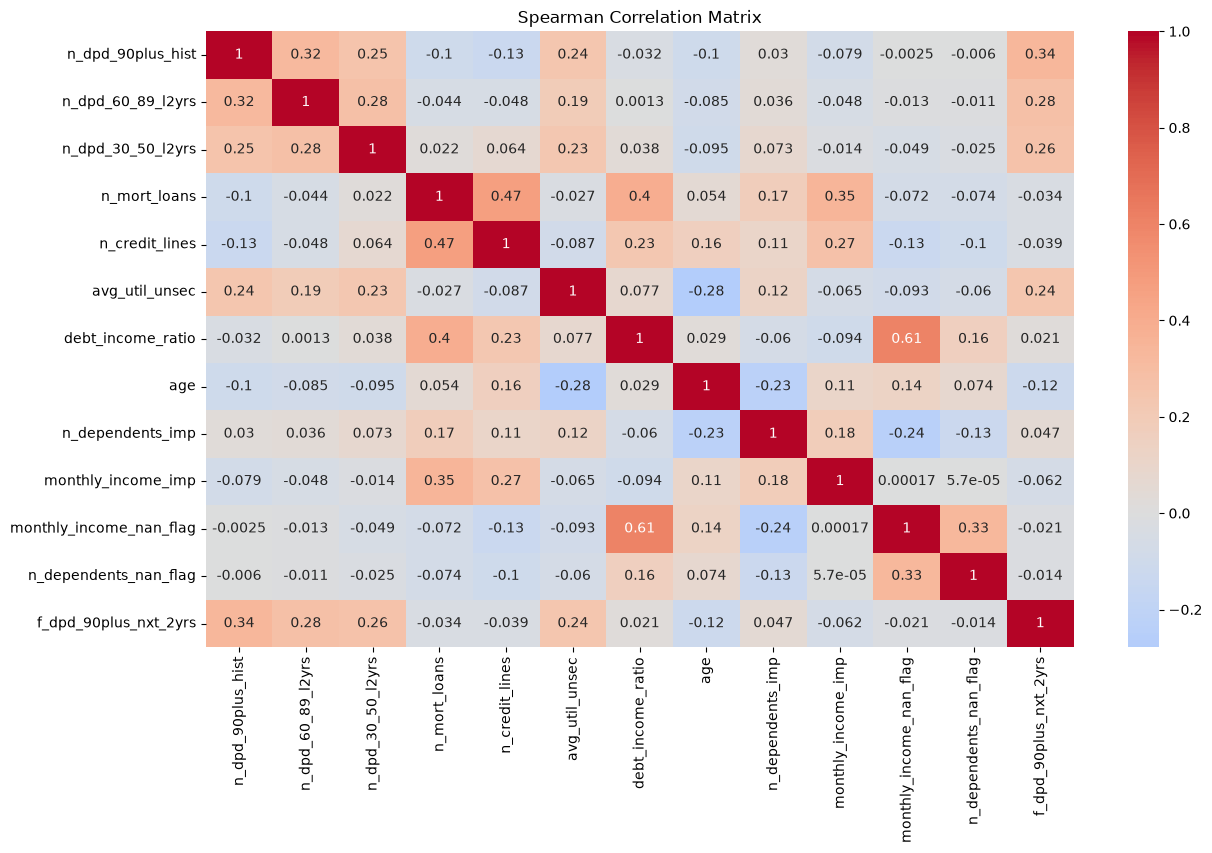

In [21]:
spearman_corr = train_data[
    ['n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs', 'n_dpd_30_50_l2yrs',
     'n_mort_loans', 'n_credit_lines', 'avg_util_unsec', 'debt_income_ratio',
     'age', 'n_dependents_imp', 'monthly_income_imp', 'monthly_income_nan_flag',
     'n_dependents_nan_flag', 'f_dpd_90plus_nxt_2yrs'
    ]
].corr(method="spearman")

# pearson_corr = train_data[
#     ['n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs', 'n_dpd_30_50_l2yrs',
#      'n_mort_loans', 'n_credit_lines', 'avg_util_unsec', 'debt_income_ratio',
#      'age', 'n_dependents_imp', 'monthly_income_imp', 'f_dpd_90plus_nxt_2yrs'
#     ]
# ].corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

## Bivariate Analysis

In [22]:
train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_util_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

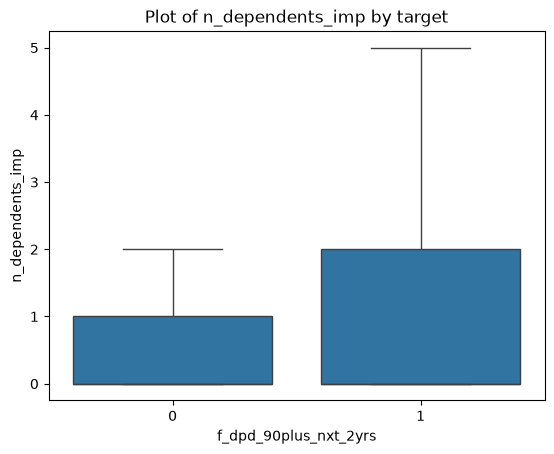

In [23]:
#n_dependents_imp
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dependents_imp", data=train_data, showfliers=False)
plt.title("Plot of n_dependents_imp by target")
plt.show()

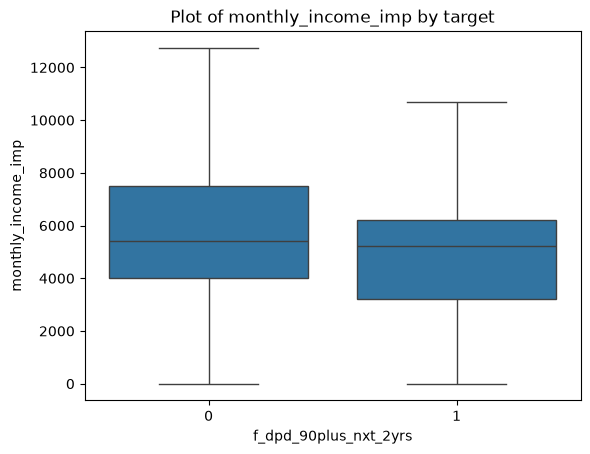

In [24]:
#monthly_income_imp
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="monthly_income_imp", data=train_data, showfliers=False)
plt.title("Plot of monthly_income_imp by target")
plt.show()

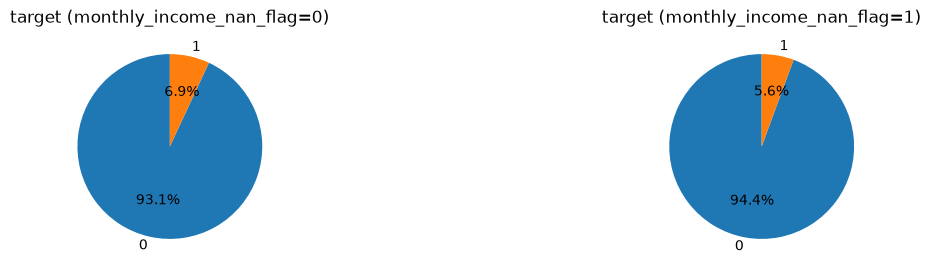

In [25]:
# Split data by monthly_income_nan_flag
df0 = train_data[train_data["monthly_income_nan_flag"] == 0]
df1 = train_data[train_data["monthly_income_nan_flag"] == 1]

# Calculate percentages for each subgroup
pct0 = df0["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100
pct1 = df1["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100

# Plot side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].pie(pct0.values, labels=pct0.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("target (monthly_income_nan_flag=0)")

axes[1].pie(pct1.values, labels=pct1.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("target (monthly_income_nan_flag=1)")
plt.show()

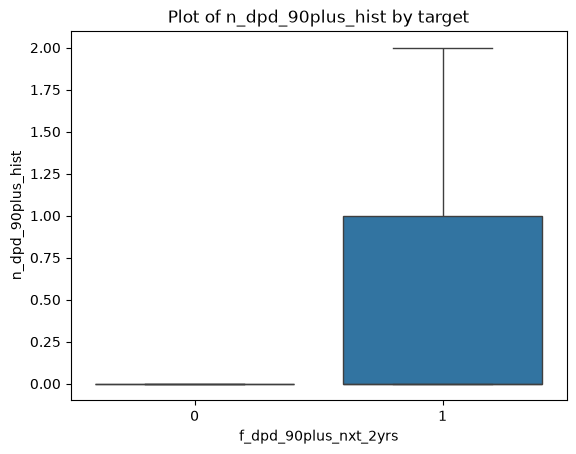

In [26]:
#n_dpd_90plus_hist
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_90plus_hist", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_90plus_hist by target")
plt.show()

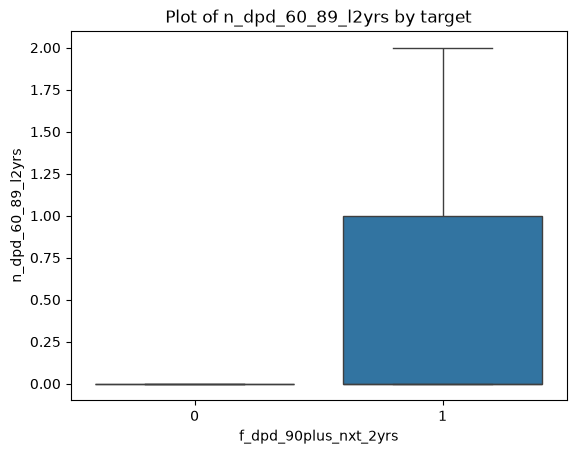

In [27]:
#n_dpd_60_89_l2yrs
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_60_89_l2yrs", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_60_89_l2yrs by target")
plt.show()

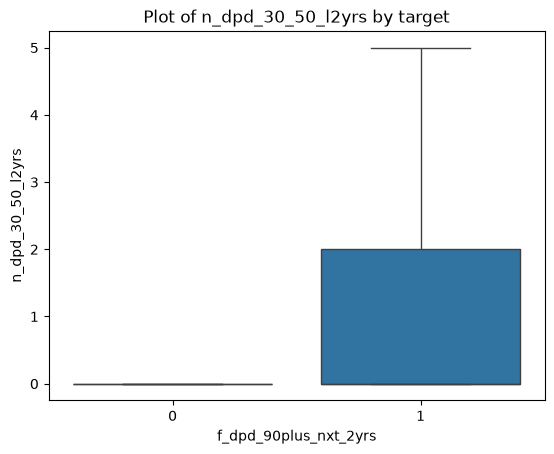

In [28]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_30_50_l2yrs", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_30_50_l2yrs by target")
plt.show()

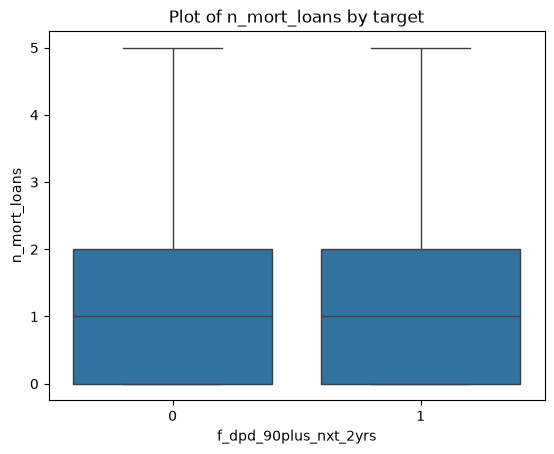

In [29]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_mort_loans", data=train_data, showfliers=False)
plt.title("Plot of n_mort_loans by target")
plt.show()

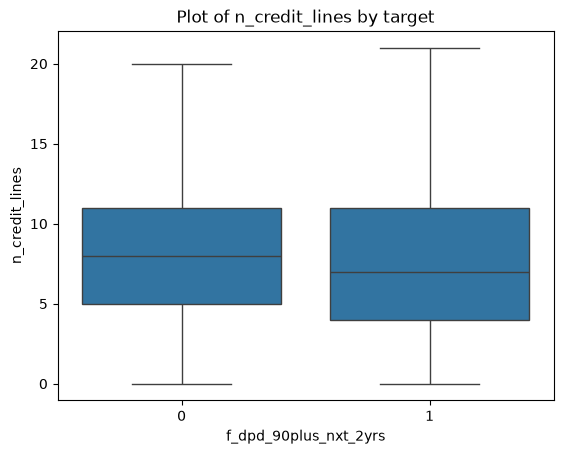

In [30]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_credit_lines", data=train_data, showfliers=False)
plt.title("Plot of n_credit_lines by target")
plt.show()

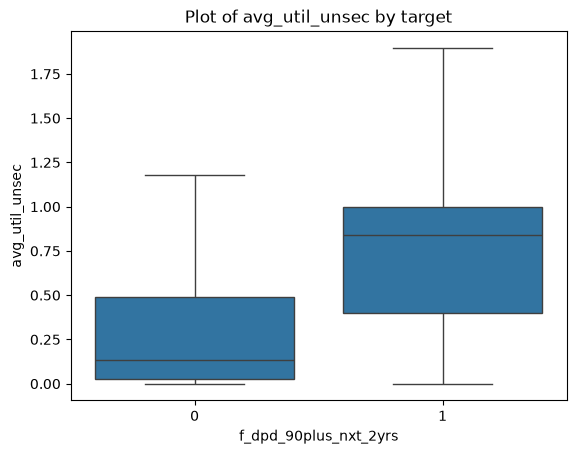

In [31]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="avg_util_unsec", data=train_data, showfliers=False)
plt.title("Plot of avg_util_unsec by target")
plt.show()

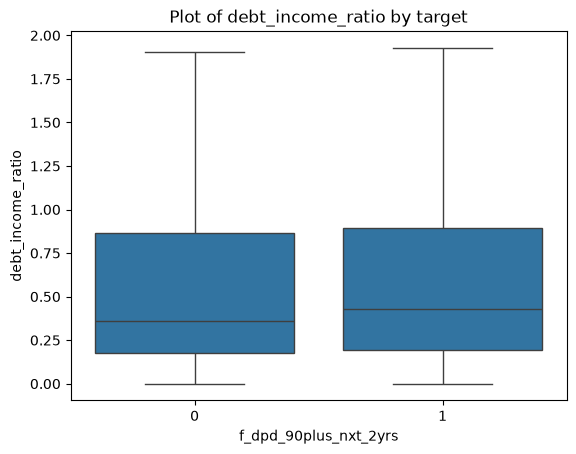

In [32]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="debt_income_ratio", data=train_data, showfliers=False)
plt.title("Plot of debt_income_ratio by target")
plt.show()

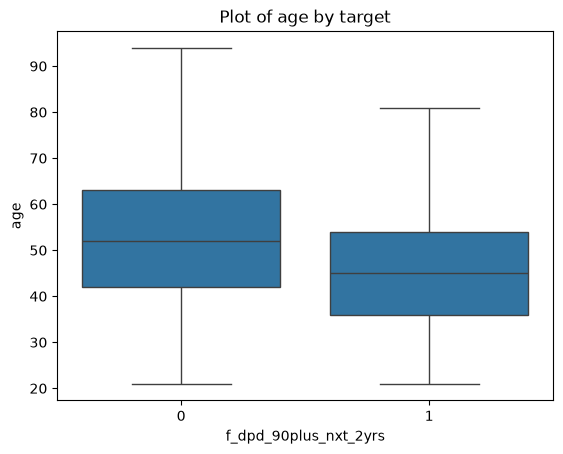

In [33]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="age", data=train_data, showfliers=False)
plt.title("Plot of age by target")
plt.show()

## Outlier Management

In [34]:
# 96, 98 in n_dpd
# 0 in age

In [36]:
print(train_data.loc[~train_data["n_dpd_90plus_hist"].isin([96, 98]), "n_dpd_90plus_hist"].median())
print(train_data.loc[~train_data["n_dpd_30_50_l2yrs"].isin([96, 98]), "n_dpd_30_50_l2yrs"].median())
print(train_data.loc[~train_data["age"].isin([0]), "age"].median())

0.0
0.0
52.0


In [78]:
uniq_cnts = train_data["n_dpd_90plus_hist"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)

n_dpd_90plus_hist
0     94.441333
1      3.495333
2      1.036667
3      0.444667
4      0.194000
98     0.176000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
96     0.003333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64


In [79]:
def impute_invalid_with_median(df, colname, invalid_values=[96, 98]):
    # Compute median excluding invalids
    valid_median = df.loc[~df[colname].isin(invalid_values), colname].median()

    # Create new column with imputation
    new_col = f"{colname}_imp"
    df[new_col] = df[colname].replace(invalid_values, valid_median)

    return df

In [80]:
train_data = impute_invalid_with_median(train_data, "n_dpd_90plus_hist")
train_data = impute_invalid_with_median(train_data, "n_dpd_60_89_l2yrs")
train_data = impute_invalid_with_median(train_data, "n_dpd_30_50_l2yrs")
train_data = impute_invalid_with_median(train_data, "age", [0])

In [81]:
train_data.drop(columns=["n_dpd_90plus_hist", "n_dpd_60_89_l2yrs", "n_dpd_30_50_l2yrs", "age"], inplace=True)

In [82]:
uniq_cnts = train_data["n_dpd_90plus_hist_imp"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)

n_dpd_90plus_hist_imp
0     94.620667
1      3.495333
2      1.036667
3      0.444667
4      0.194000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64


min_age_imp: 21 max_age: 109

mean_age: 52.29555333333333 median_age: 52.0



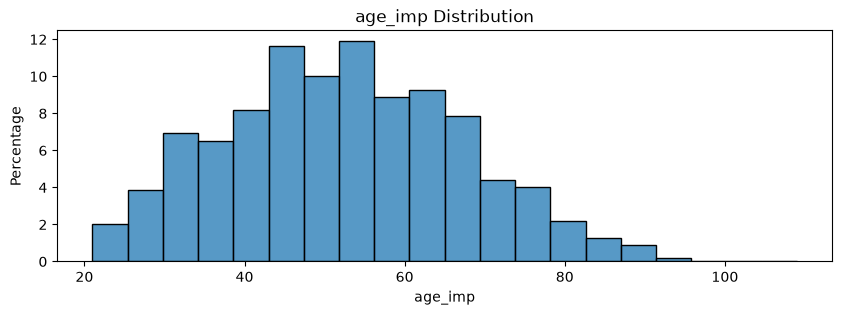

In [83]:
#age
plt.figure(figsize=(10, 3))
print("min_age_imp:", train_data["age_imp"].min(), "max_age:", train_data["age_imp"].max())
print()
print("mean_age:", train_data["age_imp"].mean(), "median_age:", train_data["age_imp"].median())
print()
sns.histplot(train_data["age_imp"], bins=20, stat="percent") 
plt.title("age_imp Distribution")
plt.xlabel("age_imp")
plt.ylabel("Percentage")
plt.show()

In [84]:
train_data.head()

,acct_id,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
0,id_1,6,13,0.766127,0.802982,1,0,0,2.0,9120.0,0,0,2,45
1,id_2,0,4,0.957151,0.121876,0,0,0,1.0,2600.0,0,0,0,40
2,id_3,0,2,0.658180,0.085113,0,0,0,0.0,3042.0,1,0,1,38
3,id_4,0,5,0.233810,0.036050,0,0,0,0.0,3300.0,0,0,0,30
4,id_5,1,7,0.907239,0.024926,0,0,0,0.0,63588.0,0,0,1,49


In [85]:
file_path = "../data/processed/train_eda_output.parquet"

if os.path.exists(file_path):
    print("File already exists!")
else:
    train_data.to_parquet(
        file_path,
        index=False
    )
    print("File created successfully!")

File created successfully!
